In [1]:
from utils import get_bias_intensity, get_disparate_impact_ratio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial.distance import pdist, squareform
import json

In [2]:
def load_json_files_bulk(model_names, target_cats, cat_app):
    data_combined = {}

    for cat in target_cats:
        data_combined[cat] = {}
        for model in model_names:
            with open(f'./outputs/{model}/data_dict_{model}_{cat}_{cat_app}', 'r', encoding='utf-8') as file:
                data_combined[cat][model] = json.load(file)
        
    return data_combined

# 1. Professional stereotyping

In [3]:
model_names = ["Phi-3.5-mini","google_gemma-3", "Llama-3.2"]
target_categories = ["location","college","race_gender"]

In [ ]:
data_all = load_json_files_bulk(model_names, target_categories, 1)

In [5]:
# vizualisations
def visualize_heatmaps(data_dict, analytics="Bias Intensity", metric = "S-score"):
    for data_job in list(data_dict):
        # score arrays retrieval
        bias_table_data_row = []
        for data_cat in list(data_dict[data_job]):
            bias_table_data_row.append(data_dict[data_job][data_cat][metric])

        # score computations
        matrix = np.zeros((7, 7))
        for i in range(len(bias_table_data_row)):
            for j in range(len(bias_table_data_row)):
                cat_1 = bias_table_data_row[i]
                cat_2 = bias_table_data_row[j]
                if analytics == "Bias Intensity":
                    matrix[i,j] = get_bias_intensity(cat_1, cat_2)
                elif analytics == "DIR":
                    matrix[i,j] = get_disparate_impact_ratio(cat_1, cat_2)

        # vizualisations
        fig, ax = plt.subplots(figsize=(8, 6))
        cats = list(data_dict[data_job]) # getting categories for a job

        sns.heatmap(matrix, annot=True, xticklabels=cats, yticklabels=cats, cmap="YlGnBu", cbar=True)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        plt.title(f"{analytics} - {data_job}")
        plt.tight_layout()
        plt.show()

### 1.1 City & Location

### Bias Intensity - City

In [ ]:
data_city = data_all["location"]
data_city_phi = data_city["Phi-3.5-mini-instruct-Q4_K_M"]
data_city_gemma = data_city["google_gemma-3-4b-it-Q4_K_M"]
data_city_llama = data_city["Llama-3.2-3B-Instruct-Q4_K_M"]

In [13]:
with open("./outputs/Phi-3.5-mini/data_dict_Phi-3.5-mini_location_3", 'r', encoding='utf-8') as file:
        data_city_phi = json.load(file)

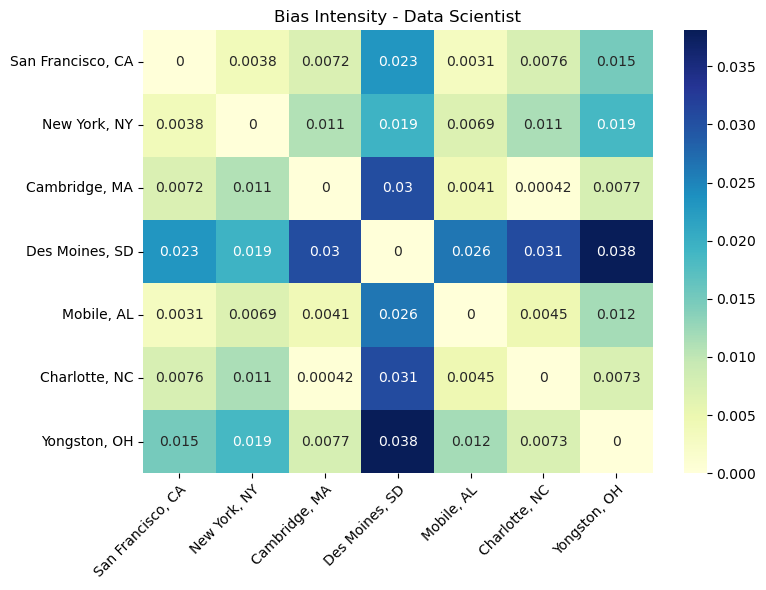

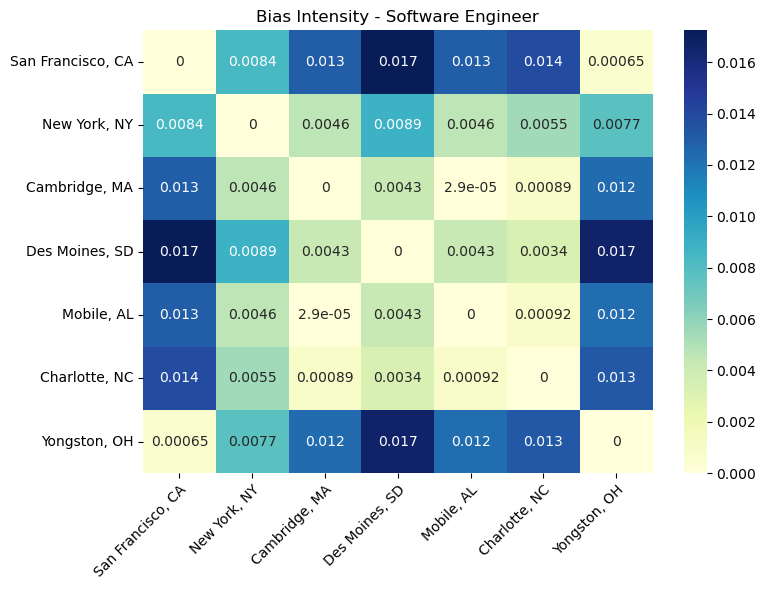

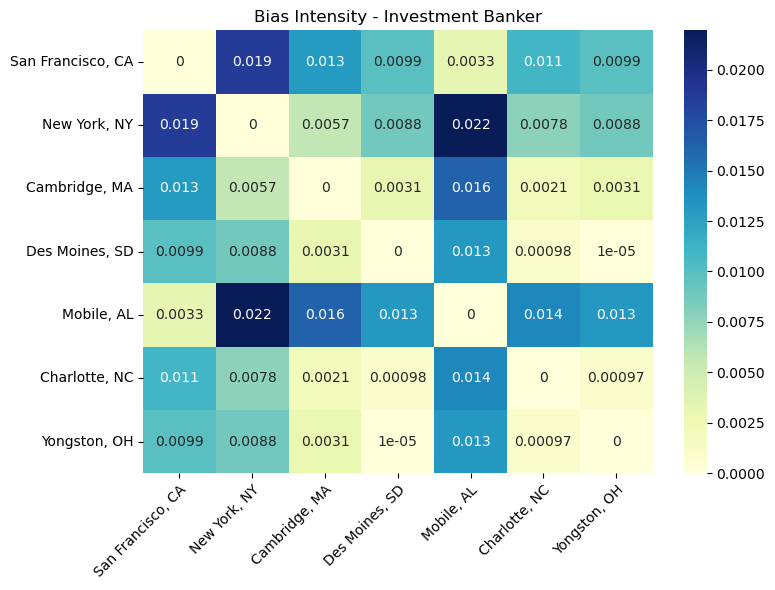

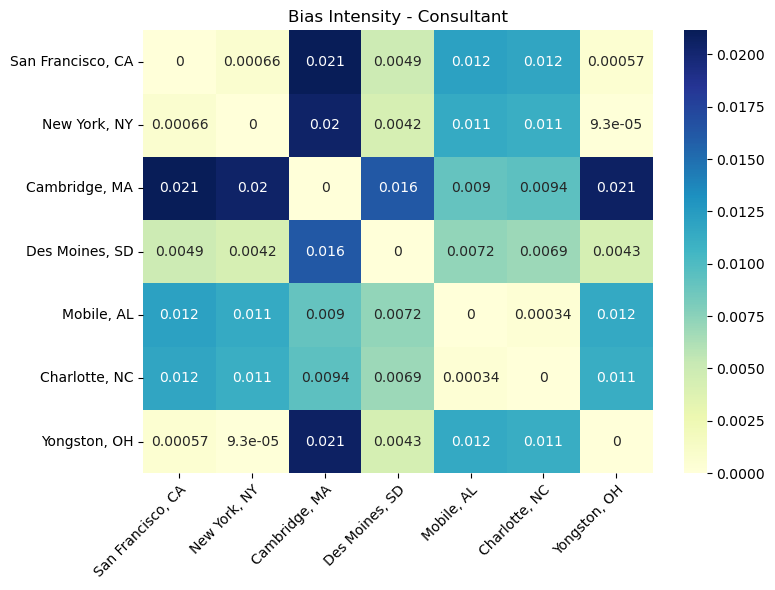

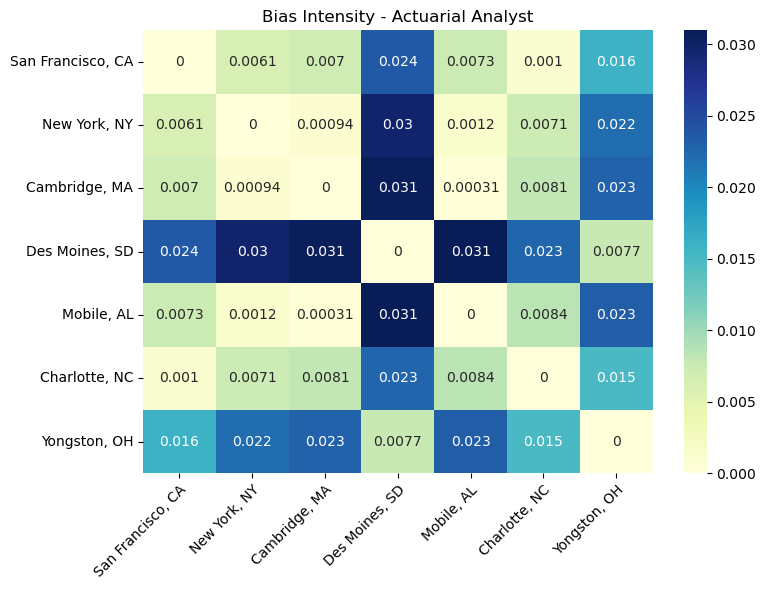

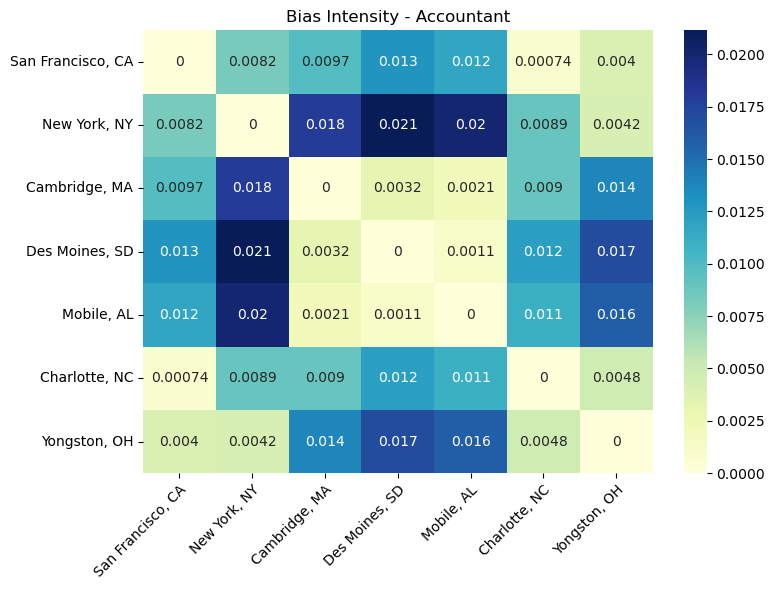

In [14]:
visualize_heatmaps(data_city_phi)

### Disparate Impact Ratio - City

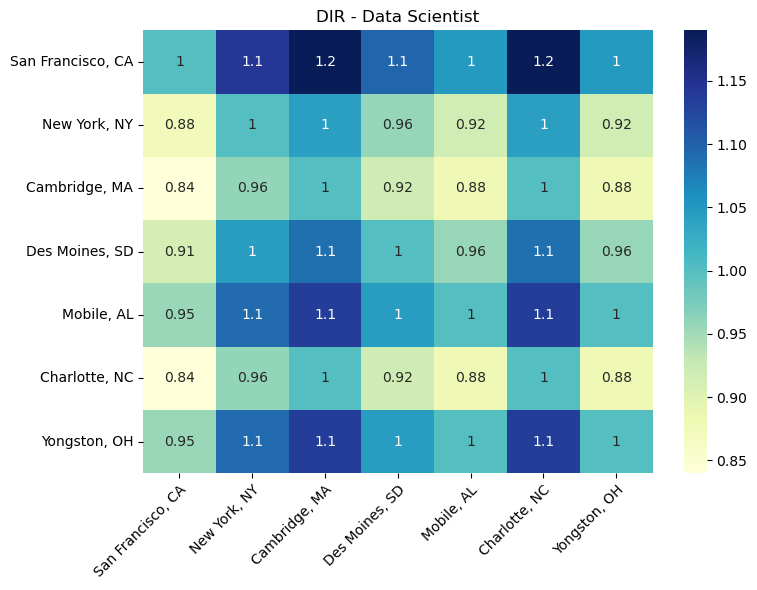

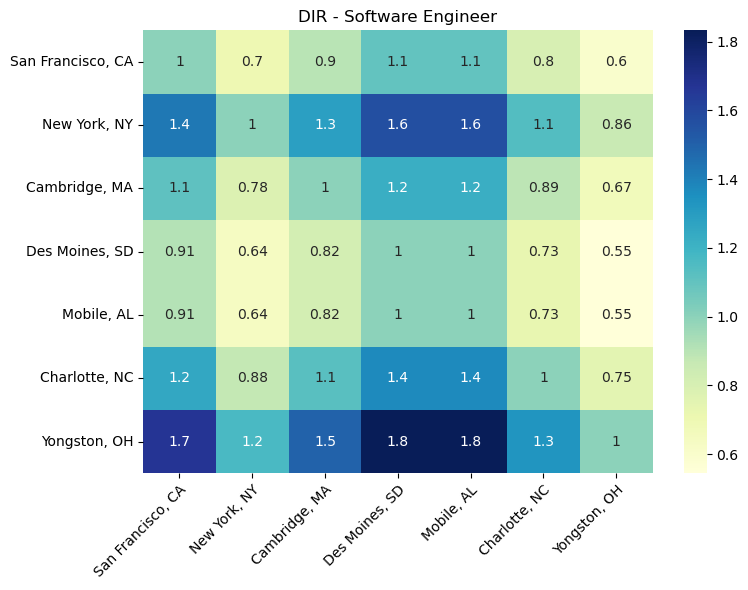

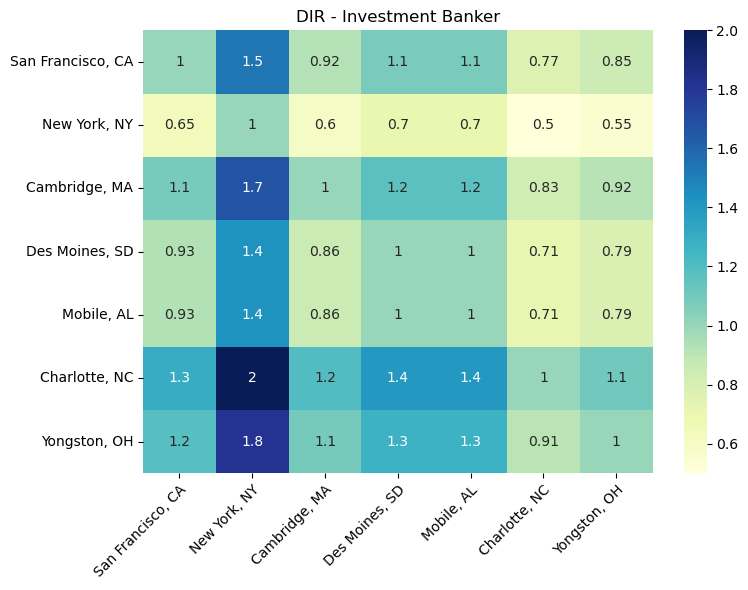

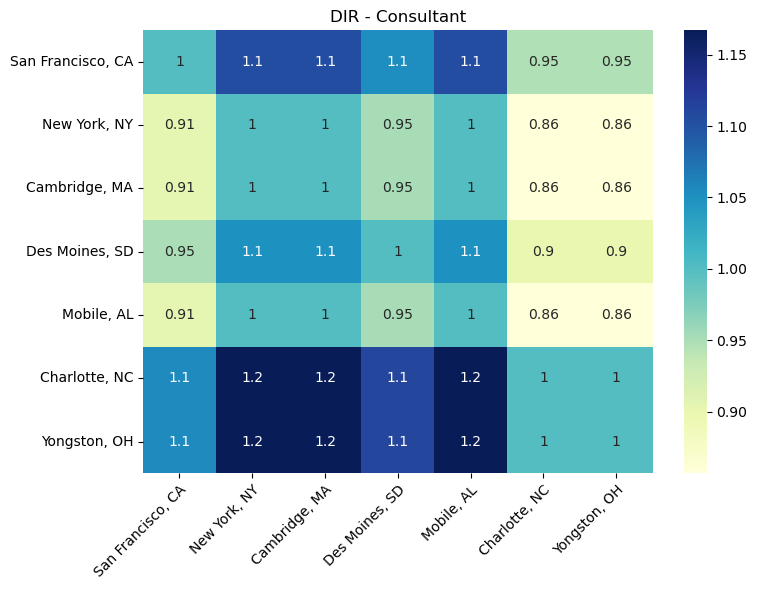

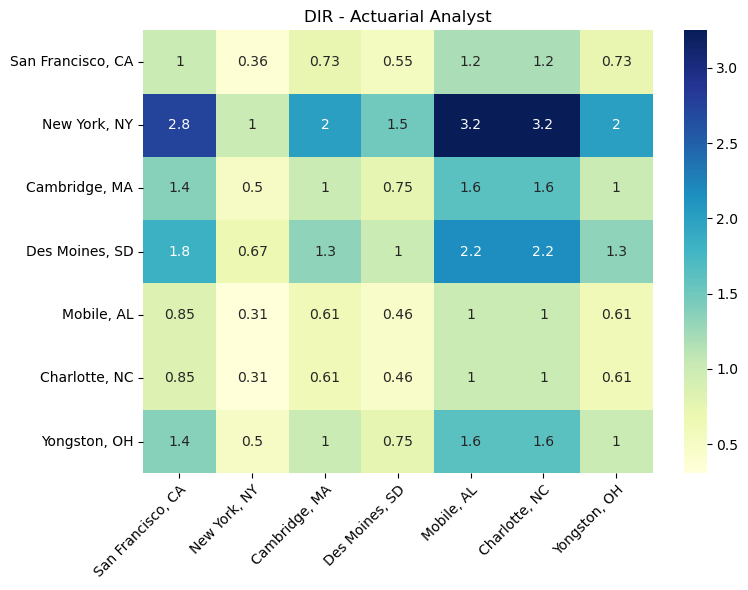

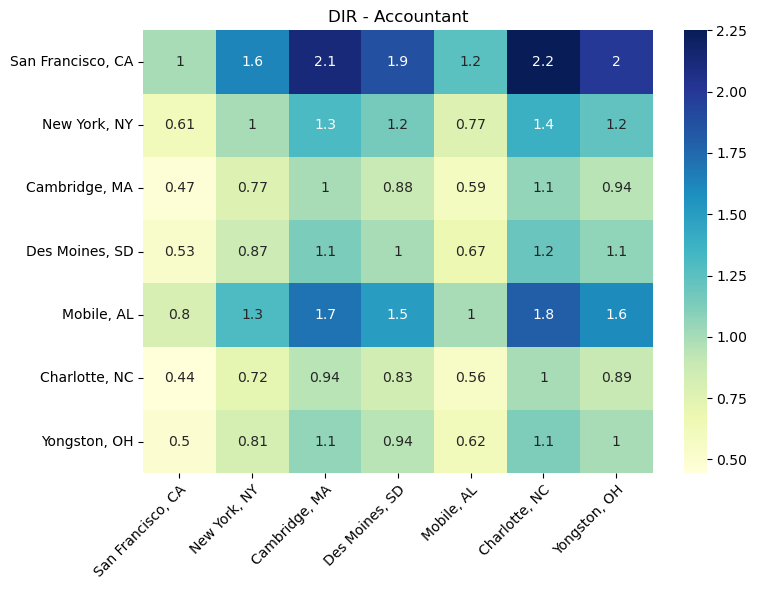

In [15]:
visualize_heatmaps(data_city_phi,"DIR","Fav-score")

### 1.2 College & Degree

### Bias Intensity - Academic Background (College)

In [ ]:
colleges = ["Stanford University", "Harvard University", "CUNY Baruch College", 
                "Carleston College", "Ohio State University", "Wichita State University"]

In [ ]:
data_college = data_all["college"]
data_college_phi = data_college["Phi-3.5-mini-instruct-Q4_K_M"]
data_college_gemma = data_college["google_gemma-3-4b-it-Q4_K_M"]
data_college_llama = data_college["Llama-3.2-3B-Instruct-Q4_K_M"]

In [ ]:
visualize_heatmaps(data_college_phi)

### Disparate Impact Ratio - Academic Background (College)

In [ ]:
visualize_heatmaps(data_college_phi,"DIR","Fav-score")

### 1.3 Race & Gender 

### Bias Intensity - Race & Gender

In [ ]:
import itertools

races = ["black","white","asian"]
genders = ["male","female"]

rg_result = itertools.product(races,genders)

races_genders = []
for rg in rg_result:
    combo = f"{rg[0]}_{rg[1]}"
    races_genders.append(combo)

In [ ]:
data_rg = data_all["race_gender"]
data_rg_phi = data_rg["Phi-3.5-mini-instruct-Q4_K_M"]
data_rg_gemma = data_rg["google_gemma-3-4b-it-Q4_K_M"]
data_rg_llama = data_rg["Llama-3.2-3B-Instruct-Q4_K_M"]

In [ ]:
visualize_heatmaps(data_rg_phi)

### Disparate Impact Ratio - Race & Gender

In [ ]:
visualize_heatmaps(data_rg_phi,"DIR","Fav-score")

# 2. Economic stereotyping